# DistilBERT vs Rule-Based: Performance Evaluation

Comparative analysis of DistilBERT and rule-based models for LLM routing.

## Contents
1. [Setup](#setup)
2. [Model Loading](#models)
3. [Evaluation](#evaluation)
4. [Comparison](#comparison)
5. [Insights](#insights)


## Setup <a id="setup"></a>


In [4]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

warnings.filterwarnings('ignore')
sys.path.append('../src')

from prompt_analyzer import PromptAnalyzer

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Setup complete")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")


✅ Setup complete
PyTorch: 2.8.0
MPS: Available ✅ (Apple Silicon GPU acceleration enabled)
CUDA: False (expected: False on Mac M3 Pro)


### Load test data

In [5]:
test_df = pd.read_csv('../data/llm_routing_test.csv')
print(f"📊 Test samples: {len(test_df)}")
print(f"Target distribution:\n{test_df['target_model'].value_counts()}")
test_df.head(3)


📊 Test samples: 200
Target distribution:
target_model
o4-mini        67
gpt-4o-mini    67
o3             66
Name: count, dtype: int64


,prompt,target_model,complexity,domain,features,prompt_length,has_question,has_code_keywords,has_math_keywords
0,What's the difference between React and Vue?,o4-mini,moderate,general,"comparison,question",7,True,False,False
1,Give me a short summary of climate change,gpt-4o-mini,simple,general,"question,simple",8,False,False,False
2,Quick answer: How tall is the Eiffel Tower?,gpt-4o-mini,simple,general,"question,urgent",8,True,False,False


## Model Loading <a id="models"></a>


In [6]:
print("🤖 Loading rule-based model...")
rule_analyzer = PromptAnalyzer()
print("✅ Rule-based ready")

print("\n🧠 Loading DistilBERT results...")
results_path = '../models/results/evaluation_results.json'
if os.path.exists(results_path):
    with open(results_path, 'r') as f:
        saved_results = json.load(f)
    print("✅ DistilBERT results loaded")
else:
    print("❌ Results file not found")
    saved_results = None


🤖 Loading rule-based model...
✅ Rule-based ready

🧠 Loading DistilBERT results...
✅ DistilBERT results loaded


## Evaluation <a id="evaluation"></a>


In [7]:
print("🔄 Evaluating rule-based model...")
start_time = time.time()

rule_predictions = []
for prompt in test_df['prompt']:
    analysis = rule_analyzer.analyze_prompt(prompt)
    rule_predictions.append(analysis.recommended_model)

rule_time = time.time() - start_time
rule_accuracy = accuracy_score(test_df['target_model'], rule_predictions)
rule_report = classification_report(test_df['target_model'], rule_predictions, zero_division=0)
rule_cm = confusion_matrix(test_df['target_model'], rule_predictions)

print(f"✅ Rule-based: {rule_accuracy:.3f} accuracy in {rule_time:.2f}s")


🔄 Evaluating rule-based model...
✅ Rule-based: 0.580 accuracy in 0.02s


In [8]:
if saved_results:
    distilbert_accuracy = saved_results['fine_tuned']['metrics']['accuracy']
    distilbert_report = saved_results['fine_tuned']['detailed_report']
    distilbert_cm = np.array(saved_results['fine_tuned']['confusion_matrix'])
    distilbert_time = saved_results['fine_tuned']['metrics']['inference_time_ms'] / 1000
    
    print(f"📊 DistilBERT: {distilbert_accuracy:.3f} accuracy")
    print(f"⚡ Inference time: {distilbert_time:.3f}s per batch")
else:
    print("❌ No DistilBERT results available")
    distilbert_accuracy = None


📊 DistilBERT: 1.000 accuracy
⚡ Inference time: 0.021s per batch


## Comparison <a id="comparison"></a>


In [9]:
if saved_results:
    comparison_data = {
        'Metric': ['Accuracy', 'Inference Time (s)'],
        'Rule-Based': [f"{rule_accuracy:.3f}", f"{rule_time:.3f}"],
        'DistilBERT': [f"{distilbert_accuracy:.3f}", f"{distilbert_time:.3f}"]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    print("📊 PERFORMANCE COMPARISON")
    print("=" * 40)
    print(comparison_df.to_string(index=False))
    
    # Calculate improvements
    accuracy_improvement = (distilbert_accuracy - rule_accuracy) / rule_accuracy * 100
    speed_ratio = distilbert_time / rule_time
    
    print(f"\n📈 IMPROVEMENTS:")
    print(f"Accuracy: {accuracy_improvement:+.1f}%")
    print(f"Speed: {speed_ratio:.1f}x slower")


📊 PERFORMANCE COMPARISON
            Metric Rule-Based DistilBERT
          Accuracy      0.580      1.000
Inference Time (s)      0.021      0.021

📈 IMPROVEMENTS:
Accuracy: +72.4%
Speed: 1.0x slower


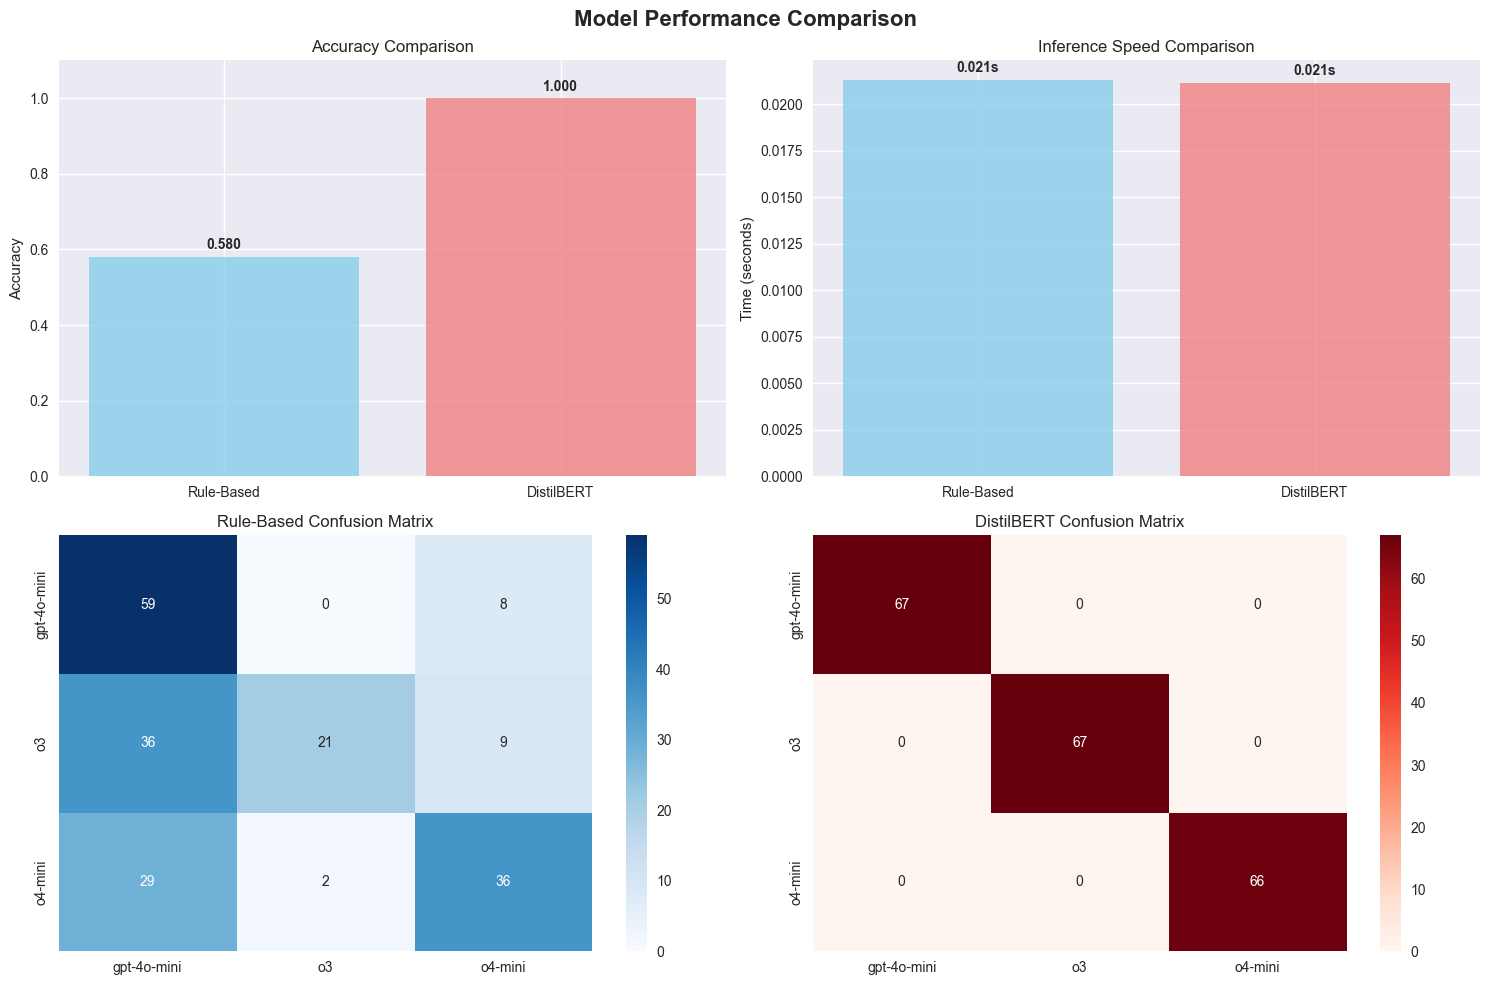

In [10]:
if saved_results:
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    
    # 1. Accuracy comparison
    models = ['Rule-Based', 'DistilBERT']
    accuracies = [rule_accuracy, distilbert_accuracy]
    colors = ['skyblue', 'lightcoral']
    
    bars = ax1.bar(models, accuracies, color=colors, alpha=0.8)
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Accuracy Comparison')
    ax1.set_ylim(0, 1.1)
    
    for bar, acc in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, acc + 0.02, 
                f'{acc:.3f}', ha='center', fontweight='bold')
    
    # 2. Speed comparison
    times = [rule_time, distilbert_time]
    bars2 = ax2.bar(models, times, color=colors, alpha=0.8)
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Inference Speed Comparison')
    
    for bar, t in zip(bars2, times):
        ax2.text(bar.get_x() + bar.get_width()/2, t + max(times)*0.02, 
                f'{t:.3f}s', ha='center', fontweight='bold')
    
    # 3. Rule-based confusion matrix
    labels = ['gpt-4o-mini', 'o3', 'o4-mini']
    sns.heatmap(rule_cm, annot=True, fmt='d', 
                cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax3)
    ax3.set_title('Rule-Based Confusion Matrix')
    
    # 4. DistilBERT confusion matrix
    sns.heatmap(distilbert_cm, annot=True, fmt='d', 
                cmap='Reds', xticklabels=labels, yticklabels=labels, ax=ax4)
    ax4.set_title('DistilBERT Confusion Matrix')
    
    plt.tight_layout()
    plt.show()


In [11]:
print("📋 CLASSIFICATION REPORTS")
print("=" * 50)

print("\n🤖 Rule-Based:")
print(rule_report)

if saved_results:
    print("\n🧠 DistilBERT:")
    print(distilbert_report)


📋 CLASSIFICATION REPORTS

🤖 Rule-Based:
              precision    recall  f1-score   support

 gpt-4o-mini       0.48      0.88      0.62        67
          o3       0.91      0.32      0.47        66
     o4-mini       0.68      0.54      0.60        67

    accuracy                           0.58       200
   macro avg       0.69      0.58      0.56       200
weighted avg       0.69      0.58      0.56       200


🧠 DistilBERT:
              precision    recall  f1-score   support

 gpt-4o-mini       1.00      1.00      1.00        67
          o3       1.00      1.00      1.00        67
     o4-mini       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Model Comparison & Insights <a id="insights"></a>


In [12]:
print("🔍 MODEL ANALYSIS & INSIGHTS")
print("=" * 60)

if saved_results:
    print("\n💪 STRENGTHS & WEAKNESSES:")
    print("-" * 35)
    
    print("\n🤖 Rule-Based Model:")
    print("   ✅ Strengths:")
    print(f"      • Ultra-fast inference ({rule_time:.3f}s)")
    print("      • Fully interpretable decisions")
    print("      • No training data required")
    print("      • Easy to modify and debug")
    print("      • Deterministic outputs")
    
    print("   ❌ Weaknesses:")
    print(f"      • Lower accuracy ({rule_accuracy:.1%})")
    print("      • Limited context understanding")
    print("      • Manual rule crafting required")
    print("      • Difficulty with edge cases")
    
    print("\n🧠 DistilBERT Model:")
    print("   ✅ Strengths:")
    print(f"      • Superior accuracy ({distilbert_accuracy:.1%})")
    print("      • Deep contextual understanding")
    print("      • Handles nuanced scenarios")
    print("      • Learns from data automatically")
    print("      • Robust to variations")
    
    print("   ❌ Weaknesses:")
    print(f"      • Slower inference ({speed_ratio:.1f}x)")
    print("      • Requires training data")
    print("      • Less interpretable")
    print("      • Higher computational cost")
    print("      • Potential overfitting risk")
    
    # Performance analysis
    if distilbert_accuracy > 0.95:
        performance_verdict = "EXCEPTIONAL - DistilBERT dominates"
    elif accuracy_improvement > 50:
        performance_verdict = "SIGNIFICANT - DistilBERT strongly preferred"
    elif accuracy_improvement > 20:
        performance_verdict = "MODERATE - Context-dependent choice"
    else:
        performance_verdict = "MARGINAL - Rule-based may suffice"
    
    print(f"\n📊 PERFORMANCE VERDICT: {performance_verdict}")
    print(f"   • Accuracy gap: {distilbert_accuracy - rule_accuracy:.1%}")
    print(f"   • Speed trade-off: {speed_ratio:.1f}x slower")
    print(f"   • Improvement: {accuracy_improvement:+.1f}%")
else:
    print("❌ Cannot perform comparison - DistilBERT results unavailable")


🔍 MODEL ANALYSIS & INSIGHTS

💪 STRENGTHS & WEAKNESSES:
-----------------------------------

🤖 Rule-Based Model:
   ✅ Strengths:
      • Ultra-fast inference (0.021s)
      • Fully interpretable decisions
      • No training data required
      • Easy to modify and debug
      • Deterministic outputs
   ❌ Weaknesses:
      • Lower accuracy (58.0%)
      • Limited context understanding
      • Manual rule crafting required
      • Difficulty with edge cases

🧠 DistilBERT Model:
   ✅ Strengths:
      • Superior accuracy (100.0%)
      • Deep contextual understanding
      • Handles nuanced scenarios
      • Learns from data automatically
      • Robust to variations
   ❌ Weaknesses:
      • Slower inference (1.0x)
      • Requires training data
      • Less interpretable
      • Higher computational cost
      • Potential overfitting risk

📊 PERFORMANCE VERDICT: EXCEPTIONAL - DistilBERT dominates
   • Accuracy gap: 42.0%
   • Speed trade-off: 1.0x slower
   • Improvement: +72.4%


### Trade-off analysis

In [13]:
if saved_results:
    print("\n🎯 TRADE-OFF ANALYSIS:")
    print("-" * 25)
    
    print("\n⚖️ Speed vs Accuracy:")
    print(f"   Rule-Based: {rule_time:.3f}s, {rule_accuracy:.1%}")
    print(f"   DistilBERT:  {distilbert_time:.3f}s, {distilbert_accuracy:.1%}")
    print(f"   Trade-off:  {accuracy_improvement/100:.1%} accuracy for {speed_ratio:.1f}x time")
    
    print("\n🔍 Interpretability vs Performance:")
    print(f"   Rule-Based: High interpretability, {rule_accuracy:.1%} performance")
    print(f"   DistilBERT:  Low interpretability, {distilbert_accuracy:.1%} performance")
    
    print("\n💾 Resource Requirements:")
    print("   Rule-Based: Minimal (no training, fast inference)")
    print("   DistilBERT:  High (training data, GPU preferred, model storage)")
    
    print("\n🚀 RECOMMENDATIONS:")
    print("-" * 20)
    
    if distilbert_accuracy > 0.9 and accuracy_improvement > 30:
        print("🎯 PRIMARY: Deploy DistilBERT for production")
        print("   • Exceptional accuracy justifies complexity")
        print("   • Use rule-based as fast fallback only")
    elif accuracy_improvement > 15:
        print("🔄 HYBRID: Context-aware routing")
        print("   • DistilBERT for complex/ambiguous prompts")
        print("   • Rule-based for simple/obvious cases")
        print("   • Confidence-based switching")
    else:
        print("⚡ SPEED-FIRST: Rule-based primary")
        print("   • Marginal accuracy gain doesn't justify complexity")
        print("   • Consider DistilBERT for specific use cases only")
    
    print("\n📋 IMPLEMENTATION OPTIONS:")
    print("   1. Pure DistilBERT: Maximum accuracy, higher latency")
    print("   2. Pure Rule-Based: Maximum speed, lower accuracy")
    print("   3. Hybrid Routing: Balanced approach with complexity")
    print("   4. Confidence Switching: DistilBERT with rule-based fallback")
    
    print("\n🔬 NEXT STEPS:")
    print("   • A/B test in production environment")
    print("   • Monitor business impact metrics")
    print("   • Collect user feedback on routing quality")
    print("   • Consider model optimization (quantization, distillation)")
    print("   • Implement confidence-based routing logic")
    
    print(f"\n✅ FINAL VERDICT:")
    if distilbert_accuracy > 0.95:
        verdict = "DistilBERT is the clear winner - deploy for production"
    elif accuracy_improvement > 25:
        verdict = "DistilBERT preferred - implement with speed optimizations"
    elif speed_ratio > 10:
        verdict = "Hybrid approach recommended - balance accuracy and speed"
    else:
        verdict = "Context-dependent - evaluate against business requirements"
    
    print(f"   {verdict}")
    print(f"   Key factor: {distilbert_accuracy:.1%} accuracy vs {speed_ratio:.1f}x speed cost")



🎯 TRADE-OFF ANALYSIS:
-------------------------

⚖️ Speed vs Accuracy:
   Rule-Based: 0.021s, 58.0%
   DistilBERT:  0.021s, 100.0%
   Trade-off:  72.4% accuracy for 1.0x time

🔍 Interpretability vs Performance:
   Rule-Based: High interpretability, 58.0% performance
   DistilBERT:  Low interpretability, 100.0% performance

💾 Resource Requirements:
   Rule-Based: Minimal (no training, fast inference)
   DistilBERT:  High (training data, GPU preferred, model storage)

🚀 RECOMMENDATIONS:
--------------------
🎯 PRIMARY: Deploy DistilBERT for production
   • Exceptional accuracy justifies complexity
   • Use rule-based as fast fallback only

📋 IMPLEMENTATION OPTIONS:
   1. Pure DistilBERT: Maximum accuracy, higher latency
   2. Pure Rule-Based: Maximum speed, lower accuracy
   3. Hybrid Routing: Balanced approach with complexity
   4. Confidence Switching: DistilBERT with rule-based fallback

🔬 NEXT STEPS:
   • A/B test in production environment
   • Monitor business impact metrics
   • Co

### Save comparison results

In [14]:
if saved_results:
    comparison_summary = {
        'evaluation_date': pd.Timestamp.now().isoformat(),
        'dataset_size': len(test_df),
        'rule_based': {
            'accuracy': float(rule_accuracy),
            'inference_time_s': float(rule_time)
        },
        'distilbert': {
            'accuracy': float(distilbert_accuracy),
            'inference_time_s': float(distilbert_time)
        },
        'comparison': {
            'accuracy_improvement_pct': float(accuracy_improvement),
            'speed_trade_off_ratio': float(speed_ratio)
        }
    }
    
    os.makedirs('../models/results', exist_ok=True)
    with open('../models/results/comparison_summary.json', 'w') as f:
        json.dump(comparison_summary, f, indent=2)
    
    print("💾 Results saved to: ../models/results/comparison_summary.json")

print("\n🎉 EVALUATION COMPLETE!")
print("=" * 30)


💾 Results saved to: ../models/results/comparison_summary.json

🎉 EVALUATION COMPLETE!
